# Merchant Segmentation & Top-10 Ranking Analysis

This notebook segments BNPL merchants into **5 retail industry categories** and ranks the **Top 10 merchants per segment** based on:
1. **Financial Scale (GMV)**: Total transaction dollar value processed.
2. **Customer Reach & Loyalty**: Distinct consumer reach and transaction volume.
3. **Average Order Value (AOV)**: Average transaction ticket size.
4. **Risk & Fraud Exposure**: Predicted fraud rate and expected fraud loss.
5. **Risk-Adjusted Merchant Performance Index (MPI)**: Normalized composite index balancing revenue scale against safety.


In [1]:
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

# Path configuration (works from root or notebooks/)
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
TABLES_DIR = PROJECT_ROOT / "data" / "tables"
PART1_DIR = TABLES_DIR / "part_1"
CURATED_DIR = PROJECT_ROOT / "data" / "curated"
OUTPUT_DIR = TABLES_DIR

# File paths
MERCHANTS_PATH = PART1_DIR / "tbl_merchants.parquet"
PREDICTIONS_CSV = TABLES_DIR / "part_2_4_fraud_probability_predictions_with_flag.csv"


/home/werew/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# ------------------------------------------------------------
# 1. Load Merchants & Define 5 Strategic Industry Segments
# ------------------------------------------------------------
merchants = pd.read_parquet(MERCHANTS_PATH)
if "merchant_abn" not in merchants.columns:
    merchants = merchants.reset_index()

# Robust tag-based segmentation function
def assign_merchant_segment(tags_str):
    """
    Classify merchants into 5 strategic retail segments based on industry tags.
    """
    if not isinstance(tags_str, str):
        return "5. Luxury, Specialty & Other"
    
    t = tags_str.lower()
    
    # 1. Fashion & Apparel
    if any(k in t for k in ["cloth", "apparel", "shoe", "fashion", "wear", "footwear", "boutique", "dress", "sportswear"]):
        return "1. Fashion & Apparel"
    
    # 2. Electronics & Technology
    elif any(k in t for k in ["electr", "tech", "comput", "digital", "gadget", "phone", "audio", "appliance", "cable", "satellite", "telecom"]):
        return "2. Electronics & Technology"
    
    # 3. Home, Living & Furniture
    elif any(k in t for k in ["furniture", "home", "interior", "hardware", "garden", "decor", "kitchen", "bedding", "lighting", "nursery"]):
        return "3. Home, Living & Furniture"
    
    # 4. Health, Beauty & Wellness
    elif any(k in t for k in ["health", "beauty", "cosmetic", "pharmacy", "wellness", "fitness", "medical", "optometrist", "salon", "spa"]):
        return "4. Health, Beauty & Wellness"
    
    # 5. Luxury, Jewelry & Specialty
    else:
        return "5. Luxury, Jewelry & Specialty"

merchants["segment"] = merchants["tags"].apply(assign_merchant_segment)

print(f"Total merchants loaded: {len(merchants):,}")
print("\nMerchants per segment:")
print(merchants["segment"].value_counts().sort_index())
display(merchants.head(10))


Total merchants loaded: 4,026

Merchants per segment:
segment
1. Fashion & Apparel               185
2. Electronics & Technology       1183
3. Home, Living & Furniture        333
4. Health, Beauty & Wellness       328
5. Luxury, Jewelry & Specialty    1997
Name: count, dtype: int64


,merchant_abn,name,tags,segment
0,10023283211,Felis Limited,"((furniture, home furnishings and equipment sh...",2. Electronics & Technology
1,10142254217,Arcu Ac Orci Corporation,"([cable, satellite, and otHer pay television a...",2. Electronics & Technology
2,10165489824,Nunc Sed Company,"([jewelry, watch, clock, and silverware shops]...","5. Luxury, Jewelry & Specialty"
3,10187291046,Ultricies Dignissim Lacus Foundation,"([wAtch, clock, and jewelry repair shops], [b]...","5. Luxury, Jewelry & Specialty"
4,10192359162,Enim Condimentum PC,"([music shops - musical instruments, pianos, a...","5. Luxury, Jewelry & Specialty"
5,10206519221,Fusce Company,"[(gift, card, novelty, and souvenir shops), (a...","5. Luxury, Jewelry & Specialty"
6,10255988167,Aliquam Enim Incorporated,"[(computers, comPUter peripheral equipment, an...",2. Electronics & Technology
7,10264435225,Ipsum Primis Ltd,"[[watch, clock, and jewelry repair shops], [c]...","5. Luxury, Jewelry & Specialty"
8,10279061213,Pede Ultrices Industries,"([computer programming , data processing, and ...",2. Electronics & Technology
9,10323485998,Nunc Inc.,"[(furniture, home furnishings and equipment sh...",2. Electronics & Technology


In [3]:
# ------------------------------------------------------------
# 2. Aggregate Transaction & Fraud Metrics per Merchant
# ------------------------------------------------------------
curated_files = sorted(CURATED_DIR.glob("*.parquet"))
merchant_stats = {}

if curated_files:
    print(f"Aggregating from {len(curated_files)} curated parquet files in {CURATED_DIR}...")
    for f in curated_files:
        print(f" - Processing {f.name}...")
        pf = pq.ParquetFile(f)
        for batch in pf.iter_batches(batch_size=250_000):
            df = batch.to_pandas()
            has_fraud = "is_fraud" in df.columns
            has_prob = "fraud_probability" in df.columns
            
            # Group by merchant_abn
            grouped = df.groupby("merchant_abn").agg(
                gmv=("dollar_value", "sum"),
                tx_count=("order_id", "count"),
                unique_users=("user_id", "nunique"),
                fraud_count=("is_fraud", "sum") if has_fraud else ("dollar_value", lambda x: 0),
                fraud_loss=("dollar_value", lambda x: x[df.loc[x.index, "is_fraud"]].sum()) if has_fraud else ("dollar_value", lambda x: 0.0),
                sum_fraud_prob=("fraud_probability", "sum") if has_prob else ("dollar_value", lambda x: 0.0)
            ).reset_index()
            
            for row in grouped.itertuples(index=False):
                abn = row.merchant_abn
                if abn not in merchant_stats:
                    merchant_stats[abn] = {
                        "merchant_abn": abn,
                        "total_gmv": 0.0,
                        "total_transactions": 0,
                        "unique_users": 0,
                        "fraud_transactions": 0,
                        "fraud_loss": 0.0,
                        "sum_fraud_prob": 0.0
                    }
                merchant_stats[abn]["total_gmv"] += float(row.gmv)
                merchant_stats[abn]["total_transactions"] += int(row.tx_count)
                merchant_stats[abn]["unique_users"] += int(row.unique_users)
                merchant_stats[abn]["fraud_transactions"] += int(row.fraud_count)
                merchant_stats[abn]["fraud_loss"] += float(row.fraud_loss)
                merchant_stats[abn]["sum_fraud_prob"] += float(row.sum_fraud_prob)
            
            del df, grouped
            gc.collect()

elif PREDICTIONS_CSV.exists():
    print(f"Aggregating from predictions CSV: {PREDICTIONS_CSV.name}...")
    chunks = pd.read_csv(PREDICTIONS_CSV, chunksize=250_000)
    for df in chunks:
        has_fraud = "is_fraud" in df.columns
        has_prob = "fraud_probability" in df.columns
        grouped = df.groupby("merchant_abn").agg(
            gmv=("dollar_value", "sum"),
            tx_count=("order_id", "count"),
            unique_users=("user_id", "nunique"),
            fraud_count=("is_fraud", "sum") if has_fraud else ("dollar_value", lambda x: 0),
            sum_fraud_prob=("fraud_probability", "sum") if has_prob else ("dollar_value", lambda x: 0.0)
        ).reset_index()
        
        for row in grouped.itertuples(index=False):
            abn = row.merchant_abn
            if abn not in merchant_stats:
                merchant_stats[abn] = {
                    "merchant_abn": abn,
                    "total_gmv": 0.0,
                    "total_transactions": 0,
                    "unique_users": 0,
                    "fraud_transactions": 0,
                    "fraud_loss": 0.0,
                    "sum_fraud_prob": 0.0
                }
            merchant_stats[abn]["total_gmv"] += float(row.gmv)
            merchant_stats[abn]["total_transactions"] += int(row.tx_count)
            merchant_stats[abn]["unique_users"] += int(row.unique_users)
            merchant_stats[abn]["fraud_transactions"] += int(row.fraud_count)
            merchant_stats[abn]["sum_fraud_prob"] += float(row.sum_fraud_prob)
        del df, grouped
        gc.collect()

# Convert dictionary to DataFrame
agg_df = pd.DataFrame.from_dict(merchant_stats, orient="index")
print(f"✓ Aggregated metrics successfully for {len(agg_df):,} merchants.")


Aggregating from 3 curated parquet files in /mnt/c/Users/werew/Downloads/MAST30034_Project_2/data/curated...
 - Processing part_2_curated.parquet...
 - Processing part_3_curated.parquet...
 - Processing part_4_curated.parquet...
✓ Aggregated metrics successfully for 4,422 merchants.


In [4]:
# ------------------------------------------------------------
# 3. Compute Financial & Risk Ratios
# ------------------------------------------------------------
merged_merchants = merchants.merge(agg_df, on="merchant_abn", how="inner")

# Average ticket size (AOV)
merged_merchants["avg_order_value"] = (
    merged_merchants["total_gmv"] / merged_merchants["total_transactions"].clip(lower=1)
).round(2)

# Fraud rate & mean fraud score
merged_merchants["fraud_rate"] = (
    merged_merchants["fraud_transactions"] / merged_merchants["total_transactions"].clip(lower=1)
).round(4)

merged_merchants["mean_fraud_prob"] = (
    merged_merchants["sum_fraud_prob"] / merged_merchants["total_transactions"].clip(lower=1)
).round(2)

# Net platform economics (3% standard take rate)
TAKE_RATE = 0.03
merged_merchants["estimated_platform_revenue"] = (merged_merchants["total_gmv"] * TAKE_RATE).round(2)
merged_merchants["net_platform_contribution"] = (
    merged_merchants["estimated_platform_revenue"] - merged_merchants["fraud_loss"]
).round(2)

# ------------------------------------------------------------
# 4. Compute Merchant Performance Index (MPI) within Segments
# ------------------------------------------------------------
def compute_segment_mpi(segment_df):
    """
    Calculate the Risk-Adjusted Merchant Performance Index (0 - 100)
    using within-segment percentile ranking.
    """
    df = segment_df.copy()
    
    # Percentile ranks within segment
    p_gmv = df["total_gmv"].rank(pct=True)
    p_users = df["unique_users"].rank(pct=True)
    p_aov = df["avg_order_value"].rank(pct=True)
    p_fraud = df["fraud_rate"].rank(pct=True)
    
    # Weighted Composite Score: Scale (40%) + Reach (30%) + Ticket Size (15%) - Fraud Penalty (15%)
    raw_score = (0.40 * p_gmv) + (0.30 * p_users) + (0.15 * p_aov) - (0.15 * p_fraud)
    
    # Rescale to 0 - 100
    score_min = raw_score.min()
    score_max = raw_score.max()
    df["performance_score"] = ((raw_score - score_min) / (score_max - score_min + 1e-6) * 100).round(2)
    df["rank_in_segment"] = df["performance_score"].rank(ascending=False, method="min").astype(int)
    
    return df.sort_values("rank_in_segment")

# Apply ranking within each of the 5 segments
ranked_merchants = (
    merged_merchants
    .groupby("segment", group_keys=False)
    .apply(compute_segment_mpi)
    .reset_index(drop=True)
)

print(f"✓ Completed ranking across {ranked_merchants['segment'].nunique()} segments.")


✓ Completed ranking across 5 segments.


/tmp/ipykernel_9046/4138697788.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_segment_mpi)


In [5]:
# ------------------------------------------------------------
# 5. Extract Top 10 Merchants per Segment & Export Results
# ------------------------------------------------------------
top_10_per_segment = (
    ranked_merchants[ranked_merchants["rank_in_segment"] <= 10]
    .sort_values(["segment", "rank_in_segment"])
    .reset_index(drop=True)
)

display_columns = [
    "segment",
    "rank_in_segment",
    "name",
    "merchant_abn",
    "performance_score",
    "total_gmv",
    "total_transactions",
    "avg_order_value",
    "unique_users",
    "fraud_rate",
    "net_platform_contribution"
]

top_10_output = top_10_per_segment[display_columns]

# Save outputs
top_10_csv_path = TABLES_DIR / "top_10_merchants_per_segment.csv"
all_ranked_csv_path = TABLES_DIR / "all_merchants_segmented_ranked.csv"

top_10_output.to_csv(top_10_csv_path, index=False)
ranked_merchants.to_csv(all_ranked_csv_path, index=False)

print(f"✓ Saved Top 10 per segment ({len(top_10_output)} rows) to: {top_10_csv_path}")
print(f"✓ Saved full ranked dataset ({len(ranked_merchants)} rows) to: {all_ranked_csv_path}")


✓ Saved Top 10 per segment (50 rows) to: /mnt/c/Users/werew/Downloads/MAST30034_Project_2/data/tables/top_10_merchants_per_segment.csv
✓ Saved full ranked dataset (4026 rows) to: /mnt/c/Users/werew/Downloads/MAST30034_Project_2/data/tables/all_merchants_segmented_ranked.csv



🏆 TOP 10 MERCHANTS: 1. FASHION & APPAREL


,rank_in_segment,name,merchant_abn,performance_score,total_gmv,total_transactions,avg_order_value,unique_users,fraud_rate,net_platform_contribution
0,1,Dolor Quisque Inc.,93558142492,100.00,8.851904e+06,21838,405.34,21652,0.0,265557.11
1,2,Turpis Foundation,78091331382,94.36,1.488740e+06,3067,485.41,3061,0.0,44662.20
2,3,Metus Inc.,17431888602,93.87,1.486738e+06,3016,492.95,3014,0.0,44602.15
3,4,Mi Felis Adipiscing Company,53062283717,92.96,1.665378e+06,4133,402.95,4124,0.0,49961.34
4,5,Integer Mollis Integer Institute,67691683330,92.28,1.447145e+06,2983,485.13,2981,0.0,43414.35
5,6,Mauris Blandit PC,71761786483,92.12,1.488195e+06,3663,406.28,3659,0.0,44645.86
6,7,Blandit At LLC,11439466003,91.97,4.882819e+06,29888,163.37,29587,0.0,146484.58
7,8,In Consequat Associates,85362139954,91.44,1.463633e+06,3468,422.04,3462,0.0,43908.98
8,9,Enim Non Nisi Corporation,56796971172,91.29,1.477053e+06,3602,410.06,3598,0.0,44311.60
9,10,In Mi Institute,61619924340,90.50,1.377509e+06,2829,486.92,2829,0.0,41325.28



🏆 TOP 10 MERCHANTS: 2. ELECTRONICS & TECHNOLOGY


,rank_in_segment,name,merchant_abn,performance_score,total_gmv,total_transactions,avg_order_value,unique_users,fraud_rate,net_platform_contribution
10,1,Nullam Enim Ltd,34096466752,100.00,9.230427e+06,18458,500.08,18345,0.0,276912.82
11,2,Neque Sed Dictum Incorporated,80518954462,99.13,8.939665e+06,29750,300.49,29450,0.0,268189.95
12,3,Sed Diam Foundation,77590625261,98.88,7.607429e+06,25179,302.13,24952,0.0,228222.87
13,4,Adipiscing Elit Foundation,45433476494,98.83,7.156934e+06,15854,451.43,15760,0.0,214708.01
14,5,Phasellus Dapibus Incorporated,90543168331,98.30,9.016103e+06,35042,257.29,34595,0.0,270483.10
15,6,Arcu Sed Eu Incorporated,35909341340,98.26,9.528214e+06,37985,250.84,37480,0.0,285846.42
16,7,Fames Ac Turpis LLC,77338620996,97.86,6.144987e+06,12308,499.27,12239,0.0,184349.62
17,8,Nec Incorporated,82368304209,97.60,9.753248e+06,5193,1878.15,5180,0.0,292597.43
18,9,Amet Risus Inc.,79827781481,97.57,9.734168e+06,4798,2028.80,4787,0.0,292025.05
19,10,Nibh Aliquam Corp.,78760357380,97.55,6.031586e+06,20225,298.22,20091,0.0,180947.57



🏆 TOP 10 MERCHANTS: 3. HOME, LIVING & FURNITURE


...

,rank_in_segment,name,merchant_abn,performance_score,total_gmv,total_transactions,avg_order_value,unique_users,fraud_rate,net_platform_contribution
30,1,Rutrum Magna Cras LLC,99291944648,100.00,7.549516e+06,15505,486.91,15425,0.0000,226485.48
31,2,A Ultricies Inc.,46012371285,99.03,4.021708e+06,8222,489.14,8194,0.0000,120651.23
32,3,Sed Nec Inc.,88699453206,98.82,5.732103e+06,11957,479.39,11905,0.0000,171963.08
33,4,A Felis Ullamcorper Industries,63817709749,98.03,3.293828e+06,6745,488.34,6728,0.0000,98814.85
34,5,Nec Orci Company,46817474676,96.31,2.751912e+06,5636,488.27,5622,0.0000,82557.37
35,6,Nec Tellus Ltd,18158387243,94.03,9.299428e+06,16223,573.22,16134,0.0001,278534.07
36,7,Hendrerit Donec Company,19986358096,93.88,2.001467e+06,4098,488.40,4092,0.0000,60044.00
37,8,Semper Pretium Corp.,52794670013,92.39,1.404359e+06,2436,576.50,2430,0.0000,42130.77
38,9,Dolor Dolor Industries,26169574842,91.61,3.206616e+06,9809,326.91,9779,0.0000,96198.47
39,10,Eget Massa Associates,13812221471,91.40,1.899795e+06,4636,409.79,4628,0.0000,56993.86



🏆 TOP 10 MERCHANTS: 5. LUXURY, JEWELRY & SPECIALTY


,rank_in_segment,name,merchant_abn,performance_score,total_gmv,total_transactions,avg_order_value,unique_users,fraud_rate,net_platform_contribution
40,1,Etiam Bibendum Industries,38700038932,100.00,9.546185e+06,7132,1338.50,7115,0.0,286385.56
41,2,Ac Ipsum LLC,80551528183,99.37,8.853616e+06,7855,1127.13,7836,0.0,265608.47
42,3,Tempus Non Lacinia Corporation,75454398468,99.05,8.074177e+06,5968,1352.91,5962,0.0,242225.30
43,4,Diam Eu Dolor LLC,90568944804,98.96,9.618325e+06,10732,896.23,10686,0.0,288549.74
44,5,Tempor Est Foundation,32709545238,98.55,9.695647e+06,12912,750.90,12849,0.0,290869.40
45,5,Semper Auctor PC,31385641294,98.55,8.378874e+06,3812,2198.03,3807,0.0,251366.22
46,7,Magna Sed Industries,98166254020,98.31,7.475497e+06,4062,1840.35,4057,0.0,224264.91
47,8,Dignissim Lacus PC,28057731482,98.04,9.366405e+06,12627,741.78,12574,0.0,280992.16
48,9,Odio Phasellus Institute,63123845164,97.79,8.630515e+06,11446,754.02,11405,0.0,258915.45
49,10,Vulputate Inc.,87084550311,97.46,6.170331e+06,4797,1286.29,4788,0.0,185109.93



📊 SEGMENT-LEVEL AGGREGATE OVERVIEW


,segment,merchant_count,total_segment_gmv,total_transactions,avg_segment_aov,avg_fraud_rate
0,1. Fashion & Apparel,185,8.645009e+07,432529,271.404919,1.621622e-06
1,2. Electronics & Technology,1183,5.964247e+08,4046876,791.749391,2.028740e-06
2,"3. Home, Living & Furniture",333,2.113445e+08,1229090,471.274535,6.006006e-07
3,"4. Health, Beauty & Wellness",328,1.724217e+08,640372,342.141738,2.743902e-06
4,"5. Luxury, Jewelry & Specialty",1997,1.090415e+09,7265808,1708.826430,8.069104e-04


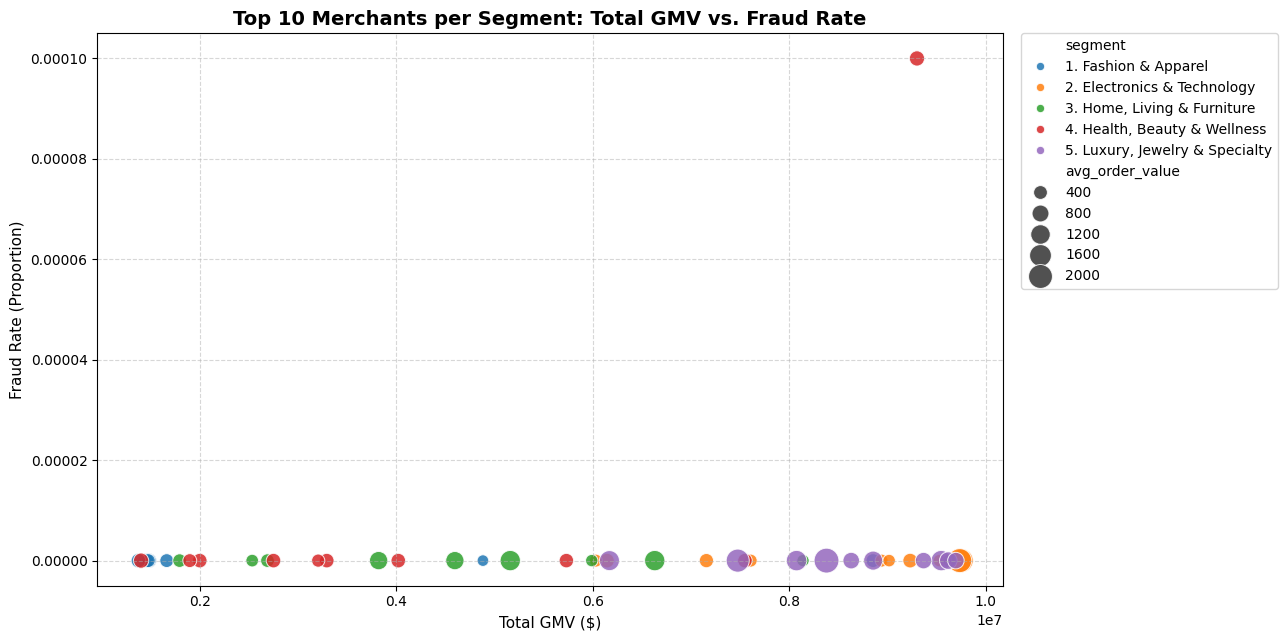

In [6]:
# ------------------------------------------------------------
# 6. Segment Summary & Top 10 Displays
# ------------------------------------------------------------
for seg in top_10_output["segment"].unique():
    print("\n" + "=" * 85)
    print(f"🏆 TOP 10 MERCHANTS: {seg.upper()}")
    print("=" * 85)
    sub = top_10_output[top_10_output["segment"] == seg].drop(columns=["segment"])
    display(sub)

# Segment-level Aggregate Overview
segment_summary = ranked_merchants.groupby("segment").agg(
    merchant_count=("merchant_abn", "count"),
    total_segment_gmv=("total_gmv", "sum"),
    total_transactions=("total_transactions", "sum"),
    avg_segment_aov=("avg_order_value", "mean"),
    avg_fraud_rate=("fraud_rate", "mean")
).reset_index()

print("\n" + "=" * 85)
print("📊 SEGMENT-LEVEL AGGREGATE OVERVIEW")
print("=" * 85)
display(segment_summary)

# Scatter plot of GMV vs Fraud Rate for Top 10 Merchants
plt.figure(figsize=(13, 6.5))
sns.scatterplot(
    data=top_10_output,
    x="total_gmv",
    y="fraud_rate",
    hue="segment",
    size="avg_order_value",
    sizes=(70, 320),
    alpha=0.85
)
plt.title("Top 10 Merchants per Segment: Total GMV vs. Fraud Rate", fontsize=14, fontweight="bold")
plt.xlabel("Total GMV ($)", fontsize=11)
plt.ylabel("Fraud Rate (Proportion)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()
